# CUBS2 full flight mission

Run the authoritative `Cubs2PatternMission` composition from `cerebri_cubs2` for its complete 70-second SIL duration. The pinned source snapshot and role of each Modelica file are documented in [`cubs2_sil/README.md`](cubs2_sil/README.md).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rumoca

## Model composition

The upstream SIL uses both similarly named files: `SportCubSIL.mo` provides the plant and `FixedWingSIL.mo` provides the inner-loop controller. `FixedWingOuterLoop.mo` is the deployed controller, while `Cubs2FlightScenarios.mo` wires all three into the single simulation model `Cubs2PatternMission`.

In [2]:
!cargo xtask repo modelica-deps ensure

    Finished `dev` profile [optimized + debuginfo] target(s) in 0.32s
     Running `/home/jgoppert/git/rumoca/target/debug/xtask repo modelica-deps ensure`


MSL 4.1.0 already cached at /home/jgoppert/git/rumoca/target/msl/ModelicaStandardLibrary-4.1.0
CMM main-a642c381 already cached at /home/jgoppert/git/rumoca/target/cmm/CMM-a642c381
Modelica dependency caches are ready.


In [3]:
scenario_path = Path("cubs2_sil/rumoca-scenario.pattern.toml")
session, model, config = rumoca.Session.from_scenario(scenario_path)
print(model.summary())
print(config)

Cubs2PatternMission — 7 states, 114 algebraic, 0 inputs, 31 outputs, 423 parameters
SimConfig(solver=Some("rk-like"), rtol=None, atol=None, dt=Some(0.02), max_wall_seconds=None)


## Full mission

The upstream pattern scenario uses `t_end = 70.0`, `dt = 0.02`, and the RK-like solver.

In [4]:
T_END = 70.0
result = model.simulate(t=(0.0, T_END), config=config)
assert np.isclose(result.time[-1], T_END)
result.metrics

{'points': 3501,
 'variables': 586,
 'compile_seconds': None,
 'simulate_seconds': 32.540842464}

In [5]:
summary = {
    "duration_s": float(result.time[-1]),
    "samples": len(result),
    "final_position_m": tuple(float(result[name][-1]) for name in ("x_m", "y_m", "z_m")),
    "final_airspeed_m_s": float(result["airspeed_m_s"][-1]),
    "laps": float(result["laps"][-1]),
    "mission_phase": float(result["mission_phase"][-1]),
}
assert np.max(result["laps"]) >= 2.0, summary
assert np.max(result["z_m"]) > 2.0, summary
assert summary["mission_phase"] == 3.0, summary
assert summary["final_position_m"][2] < 1.5, summary
summary

{'duration_s': 70.0,
 'samples': 3501,
 'final_position_m': (42.91646120665121, 0.0, 0.08629909698984971),
 'final_airspeed_m_s': 0.19571935888913194,
 'laps': 2.0,
 'mission_phase': 3.0}

## Mission trace

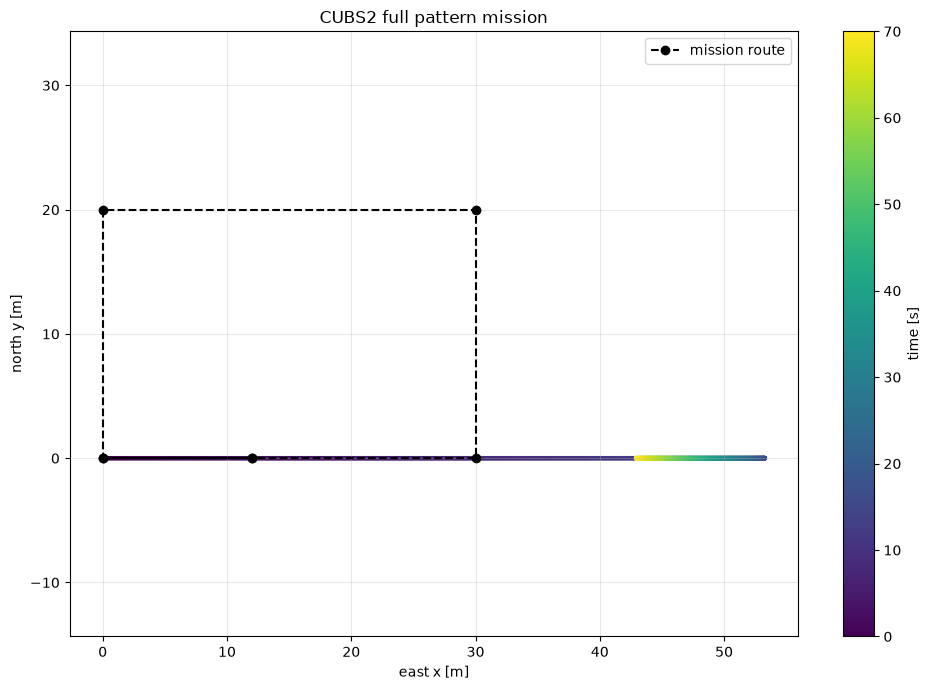

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
track = ax.scatter(result["x_m"], result["y_m"], c=result.time, s=5, cmap="viridis")
waypoints = np.array([[0, 0], [12, 0], [30, 0], [30, 20], [0, 20], [0, 0], [12, 0]])
ax.plot(waypoints[:, 0], waypoints[:, 1], "k--o", label="mission route")
ax.set(xlabel="east x [m]", ylabel="north y [m]", title="CUBS2 full pattern mission")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()
fig.colorbar(track, ax=ax, label="time [s]")
plt.tight_layout()

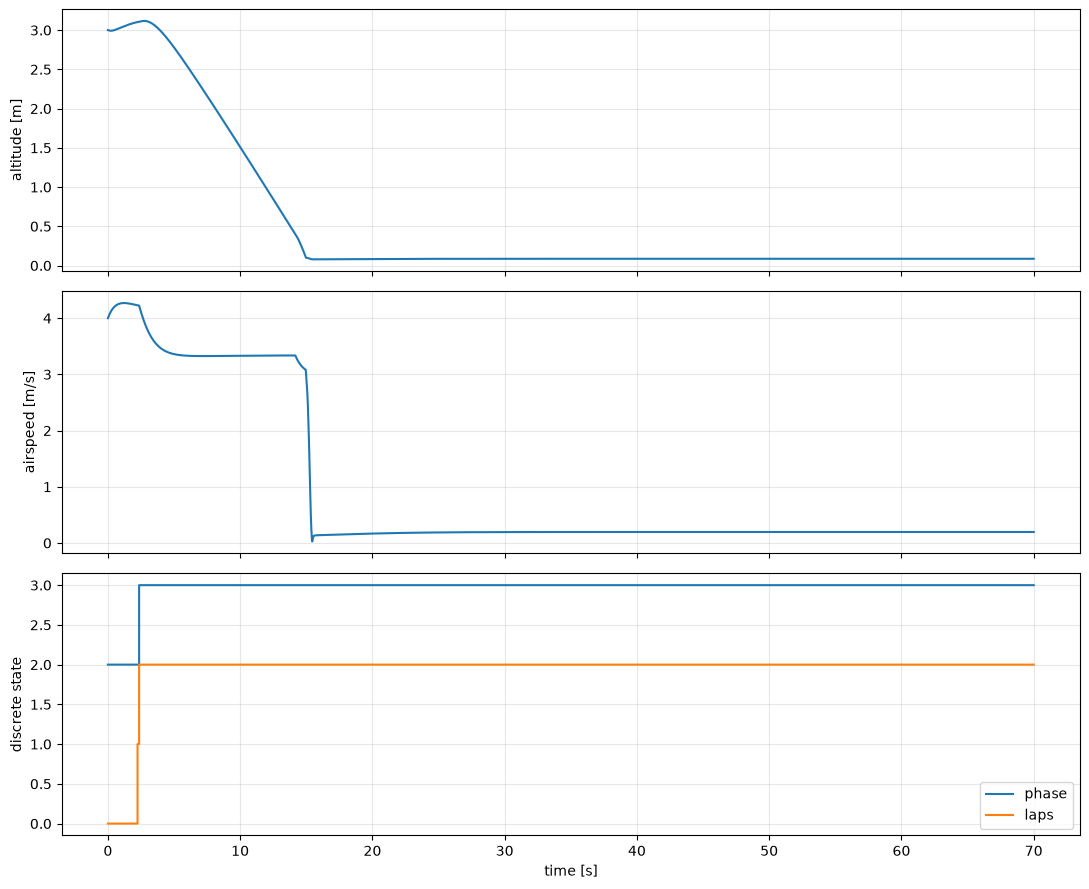

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
axes[0].plot(result.time, result["z_m"])
axes[0].set_ylabel("altitude [m]")
axes[1].plot(result.time, result["airspeed_m_s"])
axes[1].set_ylabel("airspeed [m/s]")
axes[2].step(result.time, result["mission_phase"], where="post", label="phase")
axes[2].step(result.time, result["laps"], where="post", label="laps")
axes[2].set(xlabel="time [s]", ylabel="discrete state")
axes[2].legend()
for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout()